#  💎💰 Predicting Diamond Prices using Linear Regression

---

**Background:** 

You're a data analyst working at an **online jewelry retailer**. Thousands of diamonds need to be priced each day, and qualified experts aren't always available to determine the most accurate price. The jewelry retailer is interested in developing a more **cost-effective model for diamond pricing.** 

They've asked you to **predict a reasonable market price** for each **diamond** based on its characteristics like **size, cut, and clarity**. Then, experts will use your predicted prices as a starting point to finalize pricing more quickly. 

**Task:** 

Pricing new diamonds acquired by the company, based on:
* Size
* Cut
* Clarity

**Dataset:** Past sales.

---

### **Initial Thought Process:**

- Of course, you know that larger diamonds are more valuable, but by how much? And which matters more, the cut or the clarity?

- Your plan is to start with a simple model using just one factor to predict the diamond's price, then add more factors later. 

- Neither a confidence interval nor a hypothesis test would be appropriate for this task. 

- You need to predict new prices for individual diamonds, not just perform inference on some characteristics of all diamonds. 


<img src="images/Part2-1.png" width="600">

### ***Simple linear regression***
Its is a statistical method that models the relationship between one independent variable (x) and one dependent variable (y) using a straight line, formulaically expressed as `y = mx + b`. 

It predicts the value of y based on x by finding the best-fit line that minimizes the sum of squared errors, determining both the slope (m) and intercept (b).

#### *Key Concepts of Simple Linear Regression*

Purpose: It is used to analyze the strength of the relationship between two continuous variables and to make predictions.
The Equation (y=mx+b):

- y: The predicted value of the dependent variable.

- b: The intercept, which is the value of y when x equals 0.

- m: The slope, representing the change in y for every 1-unit increase in x.

- Best Fit Line: The goal is to identify a line that minimizes the vertical distance between the data points and the line.

#### *Steps to Perform Simple Linear Regression*

- Data Preparation: Collect paired data for the independent (x) and dependent (y) variables.
  
- Model Training: Calculate the slope (m) and intercept (b) to define the line.
  
- Visualization: Plot a scatter plot of the data and draw the regression line to visualize the fit.

- Evaluation: Use metrics like R^2 to determine how well the independent variable explains the dependent variable's variability.

### *Linear Regression vs Correlation:*

**Linear regression** might sound a lot like **correlation**, which also quantifies the relationship between two features. They are indeed related techniques. However, correlation can only quantify the strength and direction of the relationship. 

<img src="images/Part2-2.png" width=600>

Linear regression involves two steps, 
- **training**
- **prediction**

1. ***Training**:*
 
    - **Analyzing** your **existing data** to **quantify the relationship** between two **features**, like carat and price.
    
    - You're looking to create a line that models the relationship, using the form `y = mx + b`.
    
    - It's called **slope-intercept form**. `m` and `b` are called **coefficients**.

    The **statistics behind linear regression** will **take your data set** and **determine the values for m and b** that **best fit the data**.

   For example, you may be looking for the equation `price = m*carat + b`. This equation quantifies the relationship between price and carat.

   *Say you **run your linear regression** and **find that the equation** that **best fits the data** is `price = 10,000*carat + 2,000`. Now you've built your model.*

3. **Prediction**:

    - Using this **trained model** to **predict y** based on the **input x**, which in this case means predicting price based on the input carat.


   *Imagine you've just received a new diamond, and it's your job to give it an appropriate price based on its carat. If you know the diamond is 0.5 carats, you can plug that into your equation, giving you a final price of $7,000.*

### *Variables:*

In linear regression terms, both features and outcomes are typically called **variables**. 

**Variable** is essentially just another term for **feature.** 

* The **independent variable** corresponds with your **input**. It's the **feature** you think is **causing part of the outcome** and is graphed on the **x-axis**. In this example, it's the carat. 

* The **dependent variable** is the **outcome you're trying to predict**. Here, it's the price of the diamond. 

And the value of price is dependent on carat, the independent variable. 

When you're trying to determine which variable is which in your data, think about **cause** (*independent variable*) and **effect** (*dependent variable*).

---

<img src="images/Part2-4.png" width=600>

---

## 📊 Step-1: Identify the Dependent Variable
First step is to identify the **dependent variable** with in our case is the `Price`.

---

## 📊 Step-2: Identify the Best Independent Variable
Next step is to identify the **best independent variable** with which to build your simple linear regression model. 

You'll need to examine **correlations and scatterplots** to achieve this goal.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

In [3]:
df = pd.read_csv("diamonds.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53941 entries, 0 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53941 non-null  float64
 1   cut      53941 non-null  object 
 2   color    53941 non-null  object 
 3   clarity  53941 non-null  object 
 4   depth    53941 non-null  float64
 5   table    53941 non-null  float64
 6   price    53941 non-null  int64  
 7   x        53941 non-null  float64
 8   y        53941 non-null  float64
 9   z        53941 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### *Understanding Relationships of Price via Pairplots*

In [6]:
# identify the numeric columns in the data
numeric_columns=["carat", "depth", "table", "x", "y", "z"] 

A **pairplot** is a data visualization tool used in exploratory data analysis (EDA) to understand the **relationships between all possible pairs of numerical variables** in a dataset.

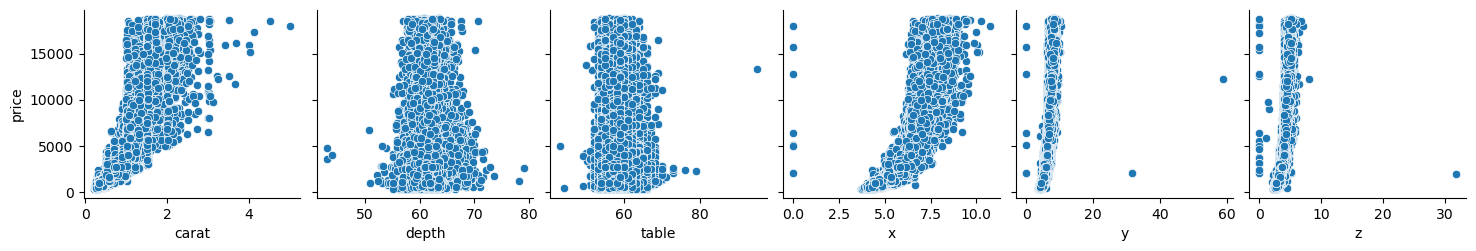

In [7]:
# we create pairplots on these numeric columns with price
sns.pairplot(df,
            y_vars=["price"],
            x_vars=numeric_columns)
plt.show()

`Depth` and `table` don't seem to have much of a noticeable relationship with price. A line through each scatterplot is relatively vertical, but `price` seems to increase as each of `carat`, `x`, `y`, and `z` increases. They may be good candidates for independent variables, but which one is best? 

### *Understanding Correlation of Price with other Numerical Features*

We use `df[columns].corr()` to **quantify the strength of these relationships**, or in other words, the **predictive power of each independent variable.**

In [8]:
columns=["carat", "depth", "table", "x", "y", "z", "price"] 

In [9]:
df[columns].corr()

,carat,depth,table,x,y,z,price
carat,1.000000,0.028266,0.181643,0.975095,0.951724,0.953389,0.921593
depth,0.028266,1.000000,-0.295735,-0.025252,-0.029301,0.094964,-0.010613
table,0.181643,-0.295735,1.000000,0.195365,0.183783,0.150955,0.127155
x,0.975095,-0.025252,0.195365,1.000000,0.974702,0.970772,0.884438
y,0.951724,-0.029301,0.183783,0.974702,1.000000,0.952007,0.865425
z,0.953389,0.094964,0.150955,0.970772,0.952007,1.000000,0.861253
price,0.921593,-0.010613,0.127155,0.884438,0.865425,0.861253,1.000000


While x, y, and z are strongly correlated with price, **carat is the most strongly correlated of all these options.**

One way of interpreting correlation here is to say that **"a diamond's carat predicts about 92% of the variability in its price."**

**Summary:**

We used both **visual**(pair plot or heatmaps) and **statistical**(correlation table) methods to **identify the most promising independent variables.** 

They helped us assess which independent variable would best explain changes in the dependent variable.

---

## 📊 Step-3: Choosing our Independent Variable

Picking one **independent variable** to develop the first simple linear regression model. 

We have selected **Carat**, as our first independent variable since it has the **strongest correlation** with our dependent variable, **Price** .

We generate a **scatterplot** of carat and price to examine this relationship in more detail. 

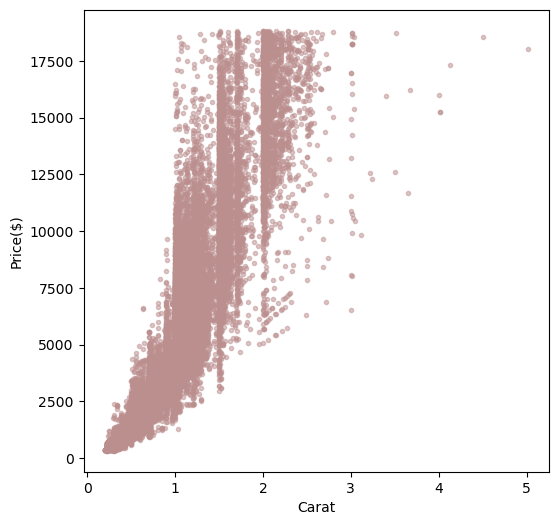

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(df["carat"], df["price"], color="RosyBrown", alpha=0.5, marker=".")
plt.xlabel("Carat")
plt.ylabel("Price($)")
plt.show()

*Well, the relationship is quite nonlinear actually. Even though this relationship is nonlinear, you can still use linear regression to model this data fairly accurately. After all, the linear correlation between these two features is quite strong.*

---

## 📊 Step-4: Training
Now we will be **training our model**.


<img src="images/Part2-5.png" width=600>

Notice that your model has two terms, m and b, even though you're only using one independent variable. **The point of b is to give your model more flexibility.** 

For example, take a look at this data. How would you draw the line of best fit through this data? You might draw the gray line. Now imagine if this line had to go through the origin at (0,0), which would be equivalent to a line of best fit with no intercept, or b equals 0. You would you draw the red line. Well, that certainly isn't a great model for this data, as it would not accurately predict y for most values of x. 

If you don't include the intercept term b, you're basically telling your model that the intercept is 0. Keeping b at 0 limits the flexibility of your model to best fit your data.

In [11]:
# To start training our linear regression model, we first import `statsmodels.api`
import statsmodels.api as sm

**Choosing x and y values:**

***Y** is straightforward, use `df["price"]`.*

*For **X**, start with your independent variable, `df["carat"]`. You'll need a bit more than that though, specifically in order to model your intercept.* 

`statsmodels` works by developing a **coefficient for each column** in your `X` data frame. 

* You want to find two coefficients, `m` and `b`. 
**m** corresponds with the **carat** column, but **what does b correspond with?**

* Right now, since there's only one column in the x data frame, StatsModels will ignore b and simply set it to zero. That rarely leads to the most accurate model. 

* In order to make sure StatsModels identifies both coefficients, m and b, you'll need to use the `sm.add_constant` function. 

In [12]:
# We set up our X and Y variables, Y for the dependent variable price, and X for the independent variable carat 
Y = df["price"]
X = df["carat"]
X = sm.add_constant(X)   # to add intercept

*Now that you've added this constant column, take a look at the resulting **data frame** `X`. You have a column for the constant, which is the same for all rows, and a column for carat.*

In [13]:
X

,const,carat
0,1.0,0.23
1,1.0,0.21
2,1.0,0.23
3,1.0,0.29
4,1.0,0.31
...,...,...
53936,1.0,0.72
53937,1.0,0.72
53938,1.0,0.70
53939,1.0,0.86


*Meanwhile, `Y` is a **series** containing only the price.*

In [14]:
Y

0         326
1         326
2         327
3         334
4         335
         ... 
53936    2757
53937    2757
53938    2757
53939    2757
53940    2757
Name: price, Length: 53941, dtype: int64

To **train** the regression model, you'll use `sm.OLS`, which stands for **ordinary least squares**. 

It's a foundational type of regression model. 

For the arguments, use y and x. You must start with y. **Regression is not symmetric**, unlike correlation.

In [15]:
# Create an Ordinary Least Squares (OLS) regression model
# Y represents the dependent variable (target)
# X represents the independent variables (features)

model = sm.OLS(Y, X)  # must start with Y

# Fit the model to the data and store the results

results = model.fit()   # training the model

In [16]:
type(results)

statsmodels.regression.linear_model.RegressionResultsWrapper

In [17]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.849
Method:                 Least Squares   F-statistic:                 3.041e+05
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:44   Log-Likelihood:            -4.7274e+05
No. Observations:               53941   AIC:                         9.455e+05
Df Residuals:                   53939   BIC:                         9.455e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2256.3385     13.055   -172.831      0.0

<img src="images/Part2-6.png" width=450>

---

### Interpreting the output of the regression model

We look out for the following:

- First, the R-squared value. 
- Second, the p-value for the coefficients, both constant and carat. 
- And last, the values of the coefficients themselves.

<img src="images/Part2-7.png" width=600>

**R-squared** (also known as the **Coefficient of Determination**) is a global metric that tells you how well your model "fits" the overall data. It ranges from 0 to 1.

- Interpretation: An R-squared of 0.849 means that **approximately 84.9% of the variance in your target variable is explained by the independent variable** (features) in your model.

- The Unexplained Part: The **remaining 15.1% of the variance is due to "noise," random error, or other factors/features** that your model hasn't accounted for yet.

<img src="images/Part2-8.png" width=600>

<img src="images/Part2-9.png" width=600>

In [18]:
# Taking an LLM's help for interpretation

<img src="images/Part2-10.png" width=600>

---

## 📊 Step-5: Prediction

The model coefficients can be used to create the equation of line of best fit. 

`y = mx + b`, or `price = m*carat + b`. 

The coefficients are stored in `results.params`, which stands for parameters. 

In [19]:
results.params  # coefficients

const   -2256.338481
carat    7756.379377
dtype: float64

In [20]:
type(results.params)

pandas.core.series.Series

*Since its a series, we can access these values using the index.*

In [21]:
m = results.params["carat"]
b = results.params["const"]

In [22]:
# We can predict the price for any given carat of diamond now

carat = 1.5
price = m*carat + b

In [23]:
print(price)

9378.230584795387


In [24]:
# Generate new possible diamonds
# Simulation: using random samples from uniform distribution

carats = np.random.uniform(low=0, high=5, size=20)

In [25]:
print(carats)  # gives a sequence of 20 values

[1.02966219 4.75227115 3.25013823 4.77239001 3.44305602 2.50920365
 2.66691915 0.33701351 4.46125557 2.22542197 2.55117142 2.44053382
 0.95038872 4.43148726 0.18503636 2.53818325 4.3487368  1.26465927
 3.55065276 2.09074246]


In [26]:
type(carats)

numpy.ndarray

In [27]:
# Applying the same equation to carats rather than carat, and saving the result in prices

prices = m*carats + b   # Vectorized element-wise operation using scalar broadcasting
prices

array([ 5730.11206619, 34604.0794966 , 22952.96663313, 34760.12899658,
       24449.31025707, 17205.99697584, 18429.29822666,   357.66618629,
       32346.85222613, 15004.87859783, 17531.51494453, 16673.36772081,
        5115.23695194, 32115.9579168 ,  -821.12626429, 17430.77377033,
       31474.11396936,  7552.83861073, 25283.87138986, 13960.25319787])

*This is the estimated prices for each diamond.*

This second price of 28396 corresponds with a diamond with 3.95 carats. That makes sense since a 3.95 carat diamond is quite large. Notice this negative value of around 1400. Well, a diamond can't have a negative price. This is a prediction for a diamond with 0.11 carats. That's quite a small one. 


<Axes: title={'center': 'Price vs. Carat'}, xlabel='carat', ylabel='price'>

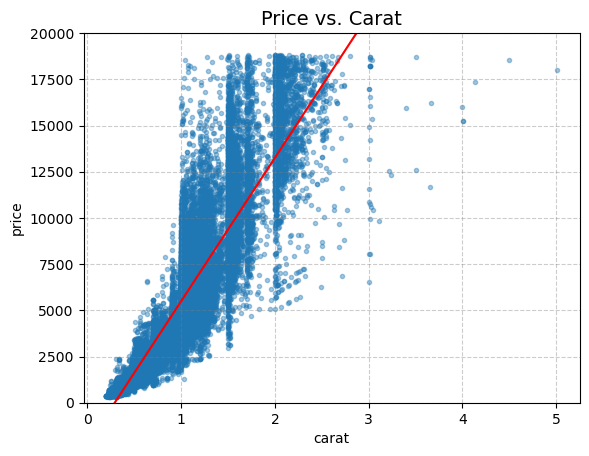

In [28]:
# create the scatter plot
plt.scatter(df["carat"], df["price"], marker=".", alpha=0.4)

# calculate the line of best fit
line = m * df["carat"] + b

plt.title("Price vs. Carat", fontsize=14)
plt.grid(color="gray", linestyle="--", alpha=0.4)

# assign "price" as the y-label
plt.ylabel("price")
plt.ylim(0,20000)

# add the line of best fit to the scatter plot
sns.lineplot(x=df["carat"], y=line, color="red")

*While `plt.scatter` shows the **actual prices**, `sns.lineplot` shows the **predicted prices**.*

This visualization answers the question: **"How much does a diamond's weight (carat) determine its price?"**

- The **dots** represent the **individual diamonds** in the dataset.

- The **red line** represents our **model's prediction.**

- The **"vertical distance"** between a dot and the red line is the **Residual** (the error in our prediction).

If most dots are close to the line, the model has high predictive power.

Looking back at the line of best fit, you may notice that the majority of your data is between 0.5 and 2.5 carats. This also seems to be the region of data that your model predicts best. 

Since you know the model's limitations, 
* You can adjust your simulation to only simulate diamonds between 0.5 and 2.5 carats.
* That way, you're using the range where the model performs best. 

Now that you've built a linear regression model with a high R-squared and known limitations, you can take it back to your client. They can use it as a starting point to estimate prices, ​speeding up the process for experts by giving them a general figure to start from. 

---

### **Multiple Linear Regression**

Your client has come back to you, saying that they need a **more accurate model** in order to adopt it. 

You decide to add the diamond's dimensions to your model. `x` represents the **length** of the diamond when viewed face up, `y` is the **width** face up, and `z` is the **height** of the diamond when standing on its point. 

In [29]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


We want to find the **line of best fit** using the dependent variable *Price* and independent variables *carat, x, y, z*

`price = m1*carat + m2*x + m3*y + m4*z +b`

In [30]:
# Making a list of predictors for X to evaluate multiple features
predictors = ["carat", "x", "y", "z"]

Y = df["price"]
X = df[predictors]

X = sm.add_constant(X)

In [31]:
X

,const,carat,x,y,z
0,1.0,0.23,3.95,3.98,2.43
1,1.0,0.21,3.89,3.84,2.31
2,1.0,0.23,4.05,4.07,2.31
3,1.0,0.29,4.20,4.23,2.63
4,1.0,0.31,4.34,4.35,2.75
...,...,...,...,...,...
53936,1.0,0.72,5.75,5.76,3.50
53937,1.0,0.72,5.69,5.75,3.61
53938,1.0,0.70,5.66,5.68,3.56
53939,1.0,0.86,6.15,6.12,3.74


In [32]:
model = sm.OLS(Y,X)
results = model.fit()

In [33]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                 7.892e+04
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:52   Log-Likelihood:            -4.7188e+05
No. Observations:               53941   AIC:                         9.438e+05
Df Residuals:                   53936   BIC:                         9.438e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1921.0000    104.372     18.405      0.0

- *`sm.ols` creates a **coefficient** for **each of the independent variables***

- Based on your *R-squared*, you really only improve your model by a little bit.

- These **coefficients are significant**, with *p-values near zero*, so you can move forward with **prediction.**

In [34]:
results.params

const     1921.000030
carat    10233.738814
x         -884.066331
y          166.013970
z         -576.311510
dtype: float64

In [35]:
b = results.params["const"]
m1 = results.params["carat"]
m2 = results.params["x"]
m3 = results.params["y"]
m4 = results.params["z"]

In [36]:
# Comparing the model's accuracy
df.loc[15000]

carat         1.04
cut        Premium
color            D
clarity        SI1
depth         61.5
table         58.0
price         5708
x             6.53
y             6.48
z              4.0
Name: 15000, dtype: object

In [37]:
carat = 1.04
x = 6.53
y = 6.48
z = 4.0
price = m1*carat + m2*x + m3*y + m4*z +b
price

np.float64(5561.659738080125)

### *Interpreting Multiple Regression Model*

- When interpreting a multiple linear regression model, you must make your conclusions considering the *entire context of the model.*

    For example, the **R-squared** value here reflects the **predictive power of the entire model**, not just one variable, like carat. 

    Your model can explain about *85.4% of price using these variables*, but you can't come to any conclusions about *how much each of these variables individually contributes to that explanatory power*. 

- **P-values and coefficients**, too, should be considered in the *context of the model.*

    The **near-zero p-value for carat** indicates that carat has a **non-zero relationship with price.**

    More specifically, if **all these other variables were held constant**, x, y, and z, then *changes in carat would still affect a diamond's price*. So, if you had two diamonds with the same dimensions, the one with the higher weight or carat would be pricier.

    So, the **coefficient for carat** explains that *a diamond's price would increase by $10,230 if it increased in weight by one carat*, as long as all the other variables are held constant.

    The **model's coefficients** help you understand the **magnitude of their impact on the price**, *but why they are impacting price is difficult to interpret.*

### *Understanding Multicollinearlity*

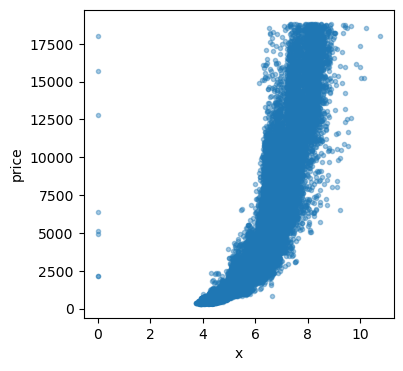

In [38]:
# Again plotting the relationship between x and price

plt.figure(figsize=(4,4))
plt.scatter(df["x"], df["price"], marker=".", alpha=0.4)
plt.xlabel("x")
plt.ylabel("price")
plt.show()

- On evaluating the plot above you see a **positive relationship**, since as x goes up, price goes up. 

- Yet, your model calculated a **negative coefficient for x**. For every one unit increase in x, your model calculates that price goes down by $884.

- This **mismatch occurs** because **both carat and x** are **strongly correlated** with your **dependent variable price** and with each other, a phenomenon called **multicollinearity**.

- When carat and x move together, it's hard for the model to untangle which one is actually driving up the price. So the model uses both variables together to capture the overall effect on the dependent variable. In practice, this can look like one variable having a positive coefficient and the other having a negative coefficient. 

<img src="images/Part2-12.png" width=500>

Multicollinearity is common because you'll often encounter datasets with many variables that overlap in what they explain. The diamonds dataset, for example, includes many measures of a diamond's weight or size, including carat, table, x, y, z, and so on, which are all related to one another. It typically doesn't affect the overall predictive power of your model, but rather it makes it harder to understand the individual impact of each independent variable.

### *Encoding Categorical Data*

- You can add **categorical variables** to your model to help **improve its performance.**

- **Color** seems like a useful potential independent variable, since it **may provide more additive prediction power** than variables like x, y, and z, which were perhaps redundant with carat.

/var/folders/6h/h489k5ln6r93tz_q7ssx2hj00000gn/T/ipykernel_41772/104332628.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x="color", y="price", order=color_order, palette="YlOrBr")


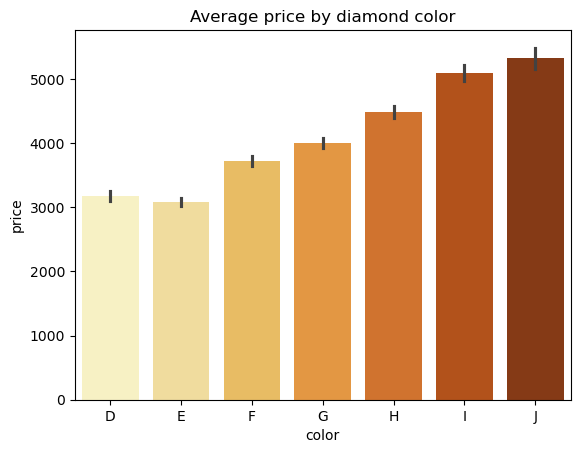

In [39]:
# Use a Seaborn bar chart to display the relationship between the color and the price

# Set the order of colors from D to J
color_order= pd.unique(df["color"].sort_values())   #["D", "E", "F", "G", "H", "I", "J"]

# Create the barplot
sns.barplot(df, x="color", y="price", order=color_order, palette="YlOrBr")

plt.title("Average price by diamond color")
plt.show()

So just looking at this graph alone with no other information, the prices for diamonds of colors D and E seem quite similar, but then the prices start to go up, increasing all the way until J. 

Based on what you know about color, that may seem incorrect. 
Why would a perfectly colorless diamond be worth less than a yellow-colored diamond? You'll want to investigate further.

In [40]:
predictors = ["carat", "color"]

Y = df["price"]
X = df[predictors]

X = sm.add_constant(pd.get_dummies(X, columns=["color"], drop_first=True, dtype=int))

In [41]:
X.head()

,const,carat,color_E,color_F,color_G,color_H,color_I,color_J
0,1.0,0.23,1,0,0,0,0,0
1,1.0,0.21,1,0,0,0,0,0
2,1.0,0.23,1,0,0,0,0,0
3,1.0,0.29,0,0,0,0,1,0
4,1.0,0.31,0,0,0,0,0,1


In [42]:
X_train = X[1000:]
X_test = X[:1000]

In [43]:
Y_train = Y[1000:]
Y_test = Y[:1000]

In [44]:
model = sm.OLS(Y_train, X_train)
results = model.fit()

In [45]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                 4.805e+04
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:57   Log-Likelihood:            -4.6119e+05
No. Observations:               52941   AIC:                         9.224e+05
Df Residuals:                   52933   BIC:                         9.225e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2136.8108     20.269   -105.421      0.0

Taking a look at the R-squared value, you **improved your model by about 1.5%** compared with the previous one. 

Looking at each coefficient's **p-value, they all appear significant**, so you can move forward with your interpretation.

### *Interpreting the Results Summary*

These regression results helped explain an interesting and surprising pattern in your data. 

- The coefficient for carat went up, so now it's about $8,000 per carat, all else being equal. 

Interpreting the coefficients for these dummy variables:

- Each color coefficient is expressed in relative terms to the category you left out, **D**. Also, there's no coefficient for D because it was dropped with drop first equals true.
- So, the coefficient for each color category is relative to D-colored diamonds.
- For example, E-colored diamonds are about 94 less expensive on average, all else being constant. Compared with D-colored diamonds, I-colored diamonds are about 1,054 ​less expensive, all else being constant.
- These coefficients are all negative because on average, ​D-colored diamonds are the priciest, as long as the carat of the diamond is the same. 

#### *An interesting revelation in the data*

Looking again at the bar graph of color and price, it originally appeared like  I and J diamonds are worth more just because of their color. 

However, these diamonds with the less desirable color tend to be larger. So, they are a higher price on average, but it's not because of their color. 

For two diamonds of the same carat, one with the color D and one with the color J, the D-colored diamond would be more valuable. 

/var/folders/6h/h489k5ln6r93tz_q7ssx2hj00000gn/T/ipykernel_41772/170706021.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, x=df["color"], y=df["price"], order=color_order, palette="YlOrBr", ax=axes[1])


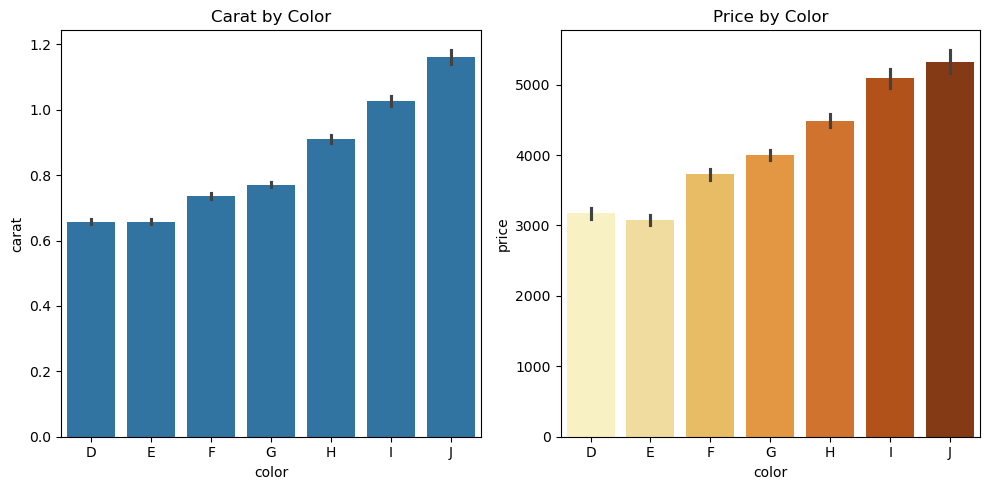

In [62]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# First subplot (left)
sns.barplot(df, x=df["color"], y=df["carat"], order=color_order, ax=axes[0])
axes[0].set_title("Carat by Color")

# Second subplot (right)
# Example for a second plot (replace with your desired second plot)
sns.barplot(df, x=df["color"], y=df["price"], order=color_order, palette="YlOrBr", ax=axes[1])
axes[1].set_title("Price by Color")

# Adjust layout and show
plt.tight_layout()
plt.show()

If you look at a Seaborne bar plot of color on the x-axis and carat on the y-axis, with the colors in order, and the same yellow to brown palette as before, you can see that the size of a diamond increases with the yellower colors. These regression results help explain an interesting and surprising pattern in your data.

### *Prediction for Multiple Linear Regression*
Once you've developed an improved model, you can use it to predict the dependent variable for new data points.

In [68]:
# Checking the 1st diamond in the X_test variable
diamond1 = X_test.loc[0]
diamond1  

const      1.00
carat      0.23
color_E    1.00
color_F    0.00
color_G    0.00
color_H    0.00
color_I    0.00
color_J    0.00
Name: 0, dtype: float64

*It's a 0.23 carat E color diamond. It's pretty small and pretty clear, but not the clearest.*

In [66]:
# Predicting its price (single set of independent variables)
results.predict(diamond1)

None   -376.053034
dtype: float64

*The model struggles somewhat with very small diamonds. So even though this is overall an excellent model, a small diamond like this one will be underpredicted.*

In [67]:
# Real price
Y_test.loc[0]

np.int64(326)

*So the model is off by about 600. In the context of diamonds worth tens of thousands of dollars, it's not a lot. But for this one, it's a pretty significant error.*

In [71]:
# Predicting new prices for the entire df X_test at once
predicted = results.predict(X_test)

In [72]:
predicted.sample(10)

776    6170.205517
922    8933.802218
386     285.899679
951    5931.444750
799    9954.373083
454    4739.968736
242    4318.431873
955     196.999401
228    3511.925434
399    1882.164995
dtype: float64

In [73]:
predicted.describe()

count     1000.000000
mean      4176.332288
std       3903.570993
min      -1631.432129
25%        995.007912
50%       3431.274790
75%       6189.103560
max      26571.057289
dtype: float64

*The mean price is around 4,200. And the highest diamond is predicted around $26,500.*

---

## Step-6: Evaluating the model

Once you've created a multiple linear regression model, you'll need to evaluate it. You already know how to interpret the result summary, but what other tools can you use? When evaluating your model, you'll need to consider metrics beyond R-squared.

<img src="images/Part2-13.png" width=700>

### *Use visualisations to compare*

In [76]:
# Predicted values of price 
y_pred = results.predict(X_test)
y_pred.head()

0    -376.053034
1    -537.354322
2    -376.053034
3    -852.813195
4   -1550.781485
dtype: float64

In [77]:
# Actual values of price 
y_actual = Y_test
y_actual.head()

0    326
1    326
2    327
3    334
4    335
Name: price, dtype: int64

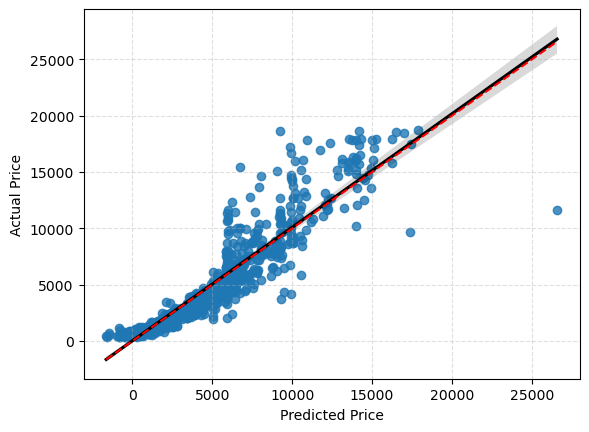

In [80]:
# Create a regression plot comparing predicted vs actual values
# This visualization helps assess model performance by showing how predictions align with actual values

sns.regplot(x=y_pred, y=y_actual, line_kws={'color':'black'})

# Adding the perfect y=x line
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.grid(linestyle="--", alpha=0.4)
plt.show()

*In an ideal world, there would be perfect, positive correlation between the predicted and actual values. 
If the actual price was 10,000, the predicted value should be 10,000. 
If this relationship were true, this graph would just be a perfect line at Y equals X.*

There is a lot of deviation around the ideal y=x line. The relationship between the predicted and actual values doesn't look linear either. There's a systematic deviation from this Y equals X line.

Since very low and very high actual prices are underpredicted, they appear mostly above this ideal line. And middle prices are overpredicted, they appear mostly below it. 

The fact that this relationship is nonlinear tells you that you may be able to get better results by using some kind of nonlinear model.

### *Understanding Multiple r*

You already know that predicted and actual prices are highly correlated, ​but you can calculate multiple R to quantify this relationship. 

In [82]:
print(type(y_pred), type(y_actual))

<class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>


In [83]:
# Since they are series, we can calculate the correlation coefficient 
y_pred.corr(y_actual)

np.float64(0.9277629181426228)

*You get a value of around 0.93, so despite being non-linearly related, ​these values are highly correlated with one another.*

### *Use residuals to understand the fit*

In [84]:
residuals = y_actual - y_pred
residuals.head()

0     702.053034
1     863.354322
2     703.053034
3    1186.813195
4    1885.781485
dtype: float64

 *So, for the first diamond, the actual price was higher than the predicted price by about $700*

### *Calculate the mean absolute errors (MAE)*

In [86]:
MAE = residuals.abs().mean()
print(MAE)

992.6128382941713


*So your predictions are on average off around $992.*

*Is that a lot? ​Well, $1,000 seems like a lot, but it depends on your use case. ​Since your model is intended to act as a starting point for a professional estimate, ​this amount of error may be fine. ​Regardless, you can present this metric to your stakeholders ​to help them understand the kinds of errors your model makes.*

-----------

<img src="images/Part2-16.png" width=700>

<img src="images/Part2-14.png" width=700>

<img src="Part2-15.png" width=550>